# Z-Gate Curves (Fig. 2c,d)

This notebook exports the **single-qubit Z-gate rotation curves** shown in Fig. 2c and Fig. 2d. The input data are released as time samples and measured state populations; the notebook converts those populations to expectation values and produces a publication-quality figure export.

## Inputs (from `data/`)
- `Q1_x_rabi_t_list_1213_1230.csv`
- `Q1_x_rabi_P_Q1_px_rabi_1213_1230.csv`, `Q1_x_rabi_P_Q1_mx_rabi_1213_1230.csv`
- `Q1_y_rabi_t_list_1213_1230.csv`
- `Q1_y_rabi_P_Q1_py_rabi_1213_1230.csv`, `Q1_y_rabi_P_Q1_my_rabi_1213_1230.csv`

Each population CSV contains two columns: `ground, excited`.

## Processing step
The plotted quantity is the Pauli expectation value derived from the excited-state population:
\[
\langle Z\rangle = 1 - 2P_e
\]

## Outputs
- `main_text_figures/fig2cd_z_gate_rotation_curves.{png,pdf}`

```mermaid
flowchart LR
  csv["CSVs in `data/`\n(t, ground/excited)"] --> z["Compute ⟨Z⟩ = 1 − 2·P_excited"]
  z --> fig["Export Fig. 2c,d curves\nPNG/PDF"]
```


In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# Resolve repository root and data path
repo_root = None
for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / 'data').exists() and (p / 'notebooks').exists():
        repo_root = p
        break
if repo_root is None:
    repo_root = Path.cwd()
os.chdir(repo_root)

load_directory = repo_root / 'data'
out_directory = repo_root / 'main_text_figures'
out_directory.mkdir(parents=True, exist_ok=True)

print('Working directory:', Path.cwd())
print('Load directory:', load_directory)


Working directory: /Users/chellymac/projects/positronium-sensing
Load directory: /Users/chellymac/projects/positronium-sensing/data


In [2]:
# Input dataset identifiers (part of the released filenames).
exp_name_ax = 'Q1_x_rabi'
date_suffix_ax = '1213_1230'
exp_name_ay = 'Q1_y_rabi'
date_suffix_ay = '1213_1230'

file_t_x = load_directory / f"{exp_name_ax}_t_list_{date_suffix_ax}.csv"
file_px = load_directory / f"{exp_name_ax}_P_Q1_px_rabi_{date_suffix_ax}.csv"
file_mx = load_directory / f"{exp_name_ax}_P_Q1_mx_rabi_{date_suffix_ax}.csv"

file_t_y = load_directory / f"{exp_name_ay}_t_list_{date_suffix_ay}.csv"
file_py = load_directory / f"{exp_name_ay}_P_Q1_py_rabi_{date_suffix_ay}.csv"
file_my = load_directory / f"{exp_name_ay}_P_Q1_my_rabi_{date_suffix_ay}.csv"

for fp in [file_t_x, file_px, file_mx, file_t_y, file_py, file_my]:
    if not fp.exists():
        raise FileNotFoundError(f'Missing required input file: {fp}')

# Load CSVs (skip the header row).
t_list_x = np.loadtxt(file_t_x, delimiter=',', skiprows=1)
P_Q1_px_rabi = np.loadtxt(file_px, delimiter=',', skiprows=1)
P_Q1_mx_rabi = np.loadtxt(file_mx, delimiter=',', skiprows=1)

t_list_y = np.loadtxt(file_t_y, delimiter=',', skiprows=1)
P_Q1_py_rabi = np.loadtxt(file_py, delimiter=',', skiprows=1)
P_Q1_my_rabi = np.loadtxt(file_my, delimiter=',', skiprows=1)

# Convert P_e to <Z>
Z_c_blue = 1.0 - 2.0 * P_Q1_mx_rabi[:, 1]   # panel c, blue squares
Z_c_green = 1.0 - 2.0 * P_Q1_px_rabi[:, 1]  # panel c, green circles

Z_d_blue = 1.0 - 2.0 * P_Q1_py_rabi[:, 1]   # panel d, blue diamonds
Z_d_green = 1.0 - 2.0 * P_Q1_my_rabi[:, 1]  # panel d, green triangles

# Restrict to the plotted time range used for the figure export.
mask_x = t_list_x <= 96
mask_y = t_list_y <= 96

t_c = t_list_x[mask_x]
t_d = t_list_y[mask_y]

Z_c_blue = Z_c_blue[mask_x]
Z_c_green = Z_c_green[mask_x]
Z_d_blue = Z_d_blue[mask_y]
Z_d_green = Z_d_green[mask_y]

print('Panel c points:', len(t_c))
print('Panel d points:', len(t_d))


Panel c points: 25
Panel d points: 25


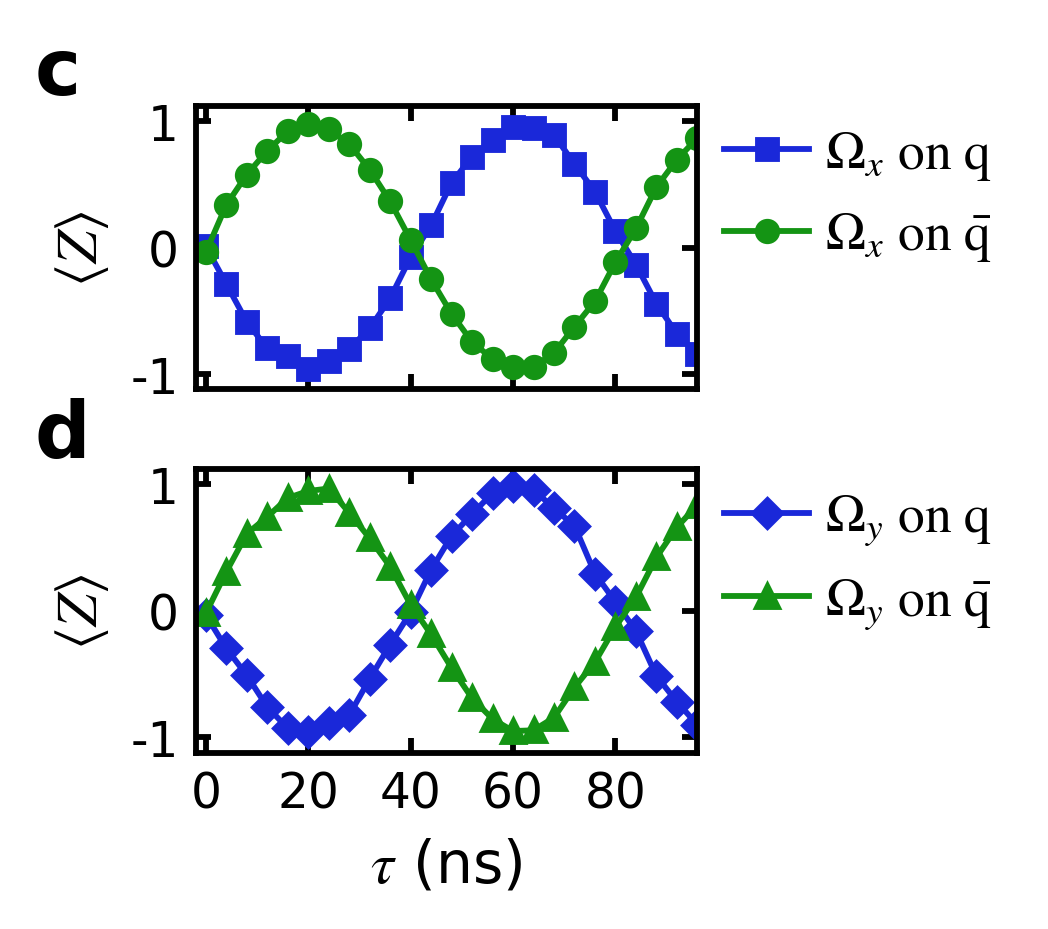

Saved: /Users/chellymac/projects/positronium-sensing/main_text_figures/fig2cd_z_gate_rotation_curves.png
Saved: /Users/chellymac/projects/positronium-sensing/main_text_figures/fig2cd_z_gate_rotation_curves.pdf


In [3]:
# Plot styling chosen for consistent manuscript-quality exports.
linewidth = 1.2
mpl.rcParams['axes.linewidth'] = linewidth
mpl.rcParams['lines.linewidth'] = linewidth
mpl.rcParams['xtick.major.width'] = linewidth
mpl.rcParams['ytick.major.width'] = linewidth
mpl.rcParams['xtick.major.size'] = 3
mpl.rcParams['ytick.major.size'] = 3
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 11
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['mathtext.rm'] = 'STIXGeneral'
mpl.rcParams['mathtext.it'] = 'STIXGeneral:italic'
mpl.rcParams['mathtext.bf'] = 'STIXGeneral:bold'

blue = '#1a28d9'
green = '#149414'

# Use a white background for publication-style figures.
fig = plt.figure(figsize=(1.85, 2.4), dpi=350, facecolor='white')
gs = fig.add_gridspec(2, 1, hspace=0.28)

# Panel c
ax_c = fig.add_subplot(gs[0, 0])
ax_c.set_facecolor('white')
ax_c.plot(t_c, Z_c_blue, color=blue, marker='s', markersize=4.2, label=r'$\Omega_x\ \mathrm{on}\ \mathrm{q}$')
ax_c.plot(t_c, Z_c_green, color=green, marker='o', markersize=4.2, label=r'$\Omega_x\ \mathrm{on}\ \bar{\mathrm{q}}$')
ax_c.set_xlim(-2, 96)
ax_c.set_ylim(-1.12, 1.12)
ax_c.set_xticks([0, 20, 40, 60, 80])
ax_c.set_xticklabels([])
ax_c.set_yticks([-1, 0, 1])
ax_c.set_yticklabels(['-1', '0', '1'])
ax_c.tick_params(direction='in', top=True, right=True)
ax_c.set_ylabel(r'$\langle Z \rangle$')
# Place legend outside the axis to prevent overlap with curves
ax_c.legend(loc='upper left', bbox_to_anchor=(1.01, 1.00), frameon=False, handlelength=1.6, handletextpad=0.3, borderaxespad=0.0)
ax_c.text(-0.32, 1.04, 'c', transform=ax_c.transAxes, fontsize=16, fontweight='bold')

# Panel d
ax_d = fig.add_subplot(gs[1, 0])
ax_d.set_facecolor('white')
ax_d.plot(t_d, Z_d_blue, color=blue, marker='D', markersize=4.0, label=r'$\Omega_y\ \mathrm{on}\ \mathrm{q}$')
ax_d.plot(t_d, Z_d_green, color=green, marker='^', markersize=4.4, label=r'$\Omega_y\ \mathrm{on}\ \bar{\mathrm{q}}$')
ax_d.set_xlim(-2, 96)
ax_d.set_ylim(-1.12, 1.12)
ax_d.set_xticks([0, 20, 40, 60, 80])
ax_d.set_yticks([-1, 0, 1])
ax_d.set_yticklabels(['-1', '0', '1'])
ax_d.tick_params(direction='in', top=True, right=True)
ax_d.set_ylabel(r'$\langle Z \rangle$')
ax_d.set_xlabel(r'$\tau$ (ns)')
# Place legend outside the axis to prevent overlap with curves
ax_d.legend(loc='upper left', bbox_to_anchor=(1.01, 1.00), frameon=False, handlelength=1.6, handletextpad=0.3, borderaxespad=0.0)
ax_d.text(-0.32, 1.04, 'd', transform=ax_d.transAxes, fontsize=16, fontweight='bold')

out_png = out_directory / 'fig2cd_z_gate_rotation_curves.png'
out_pdf = out_directory / 'fig2cd_z_gate_rotation_curves.pdf'
fig.savefig(out_png, bbox_inches='tight', facecolor='white')
fig.savefig(out_pdf, bbox_inches='tight', facecolor='white')
plt.show()

print('Saved:', out_png)
print('Saved:', out_pdf)



